<a href="https://colab.research.google.com/github/JYP163/awesome-chatgpt-prompts-zh/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-rabx5ya5
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-rabx5ya5
  Resolved https://www.github.com/mouseland/cellpose.git to commit 6d23968d924fc3b8e419a2d79349888f4b07aa29
  Preparing metadata (setup.py) ... done


In [13]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import os

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

2026-02-01 13:37:03,281 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-02-01 13:37:03,282 [INFO] 
cellpose version: 	4.0.9.dev5+g6d23968d9 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.9.0+cu126
2026-02-01 13:37:03,284 [INFO] ** TORCH CUDA version installed and working. **
2026-02-01 13:37:03,286 [INFO] ** TORCH CUDA version installed and working. **
2026-02-01 13:37:03,287 [INFO] >>>> using GPU (CUDA)
2026-02-01 13:37:05,639 [INFO] >>>> loading model /root/.cellpose/models/cpsam


**Input directory with your images:**

In [14]:
import os
from pathlib import Path
from natsort import natsorted

# 1. 设定路径
dir = Path("/content/drive/MyDrive/all-pictures")

if not dir.exists():
    raise FileNotFoundError("找不到目录，请检查路径！")

# 2. 设定你要处理的所有格式 (这里把 jpg 和 tif 都加进去了)
# 注意：代码会自动处理大小写，所以不用担心 .JPG 或 .TIF
allowed_extensions = {".tif", ".tiff", ".jpg", ".jpeg", ".png"}

# 3. 获取文件列表 (筛选后缀，并排除含有 '_masks' 或 '预览' 的文件)
files = natsorted([
    f for f in dir.glob("*")
    if f.suffix.lower() in allowed_extensions       # 检查后缀名是否在允许列表中
    and "_masks" not in f.name                      # 排除 Mask 结果文件
    and "预览" not in f.name                        # 排除你列表里的那个 "_彩色预览.jpg"
    and not f.name.startswith(".")                  # 排除隐藏文件
])

# 4. 检查结果
if len(files) == 0:
    raise FileNotFoundError("没有找到任何图片！请检查文件夹是否为空。")
else:
    print(f"✅ 成功识别到 {len(files)} 张图片：")
    # 打印前5个确认一下
    for f in files[:5]:
        print(f"  - {f.name}")
    print("  ... 等等")

✅ 成功识别到 36 张图片：
  - 1243-04.jpg
  - 1244-05.jpg
  - 拍摄-1230-图像导出-34.jpg
  - 拍摄-1231-图像导出-35.jpg
  - 拍摄-1232-图像导出-36.jpg
  ... 等等


In [15]:
img = io.imread(files[0])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (2464, 2056, 3). Assuming channel dimension is last with 3 channels


In [16]:
first_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '2' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]

2026-02-01 13:37:57,817 [INFO] processing image with (2464, 2056) HW, and 3 channels


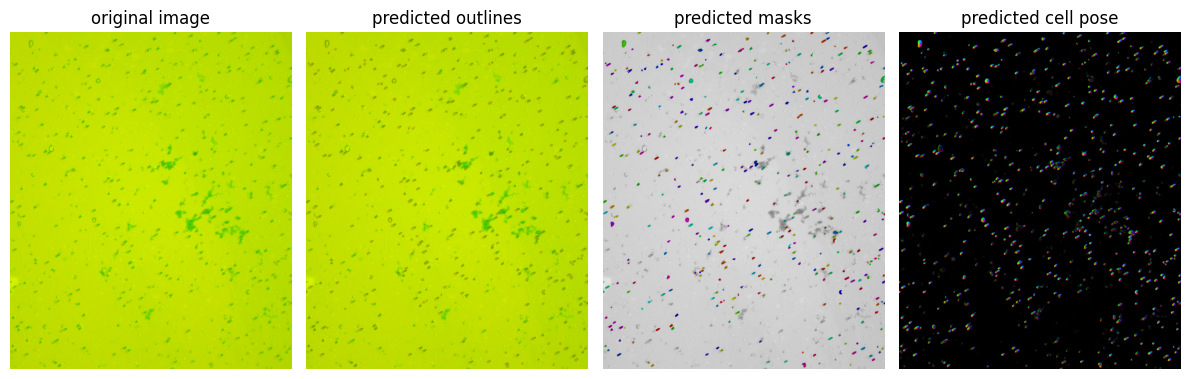

In [17]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



img_selected_channels = np.zeros_like(img)
img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from cellpose import plot, io as cp_io
import matplotlib.pyplot as plt
from skimage import io
from tqdm import trange # 确保你也导入了 trange
from pathlib import Path

# --- 0. 准备工作 ---
# 假设 files 和 model 已经在你之前的代码中定义好了
# files = ...
# model = ...

# --- 设置自定义保存路径 (放在循环之前!) ---
custom_save_path = "/content/drive/MyDrive/output-pictures"
output_dir = Path(custom_save_path)
output_dir.mkdir(parents=True, exist_ok=True) # 确保文件夹存在

# --- 1. 参数设置 ---
safe_channels = [1, 2] # [主通道, 核通道]
results = []
masks_ext = ".png" # 定义掩膜格式

print(f"🚀 开始批量处理，结果将保存至: {output_dir}")

# --- 2. 开始循环处理 ---
for i in trange(len(files)):
    f = files[i]

    # 读取图片
    img = io.imread(f)

    # 运行 Cellpose 预测
    masks, flows, styles = model.eval(img, diameter=None, channels=safe_channels)

    # 统计计数
    cell_count = np.max(masks)
    results.append({"文件名": f.name, "细胞数量": cell_count})

    # --- 3. 保存可视化预览图 (在此处缩进，确保每张都存) ---
    # 生成彩色轮廓图
    view_img = plot.mask_overlay(img, masks)
    # 构造保存路径
    preview_path = output_dir / (f.stem + "_彩色预览.jpg")
    io.imsave(preview_path, view_img)

    # --- 4. 保存 Mask 数据 (在此处缩进，确保每张都存) ---
    mask_path = output_dir / (f.stem + "_masks" + masks_ext)
    io.imsave(mask_path, masks)

    # --- 5. 保存 ROI (在此处缩进，确保每张都存) ---
    try:
        # 构造不带后缀的目标文件名用于 ROI 保存
        target_file_path = output_dir / f.name
        cp_io.save_rois(masks, target_file_path)
    except Exception as e:
        print(f"⚠️ {f.name} ROI保存失败: {e}")

    # (可选) 打印进度
    # print(f"已保存: {f.name} (细胞数: {cell_count})")

# --- 6. 循环结束后，导出汇总表 ---
df = pd.DataFrame(results)
summary_path = output_dir / "细胞计数汇总表.csv"
df.to_csv(summary_path, index=False, encoding='utf_8_sig')

print(f"\n✅ 全部完成！")
print(f"📊 计数汇总已存至: {summary_path}")
print(f"🖼️ 所有结果图片已保存至: {output_dir}")

# --- 7. 展示最后一张图作为示例 ---
plt.figure(figsize=(10, 10))
plt.imshow(view_img)
plt.title(f"Last Image Result: {cell_count} cells")
plt.axis('off')
plt.show()

🚀 开始批量处理，结果将保存至: /content/drive/MyDrive/output-pictures


  0%|          | 0/36 [00:00<?, ?it/s]

2026-02-01 14:17:37,557 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-02-01 14:17:37,562 [INFO] processing image with (2464, 2056) HW, and 3 channels


/usr/local/lib/python3.12/dist-packages/skimage/_shared/utils.py:328: UserWarning: /content/drive/MyDrive/output-pictures/1243-04_masks.png is a low contrast image
  return func(*args, **kwargs)
  3%|▎         | 1/36 [00:58<34:05, 58.43s/it]

2026-02-01 14:18:35,969 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-02-01 14:18:35,975 [INFO] processing image with (2464, 2056) HW, and 3 channels
